# Data Generation

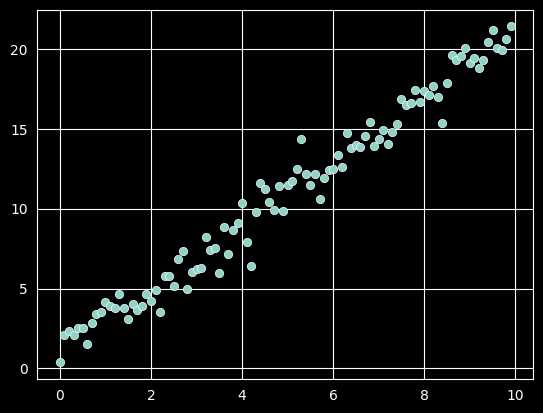

In [62]:
import matplotlib.pyplot as plt
import  numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

x = np.arange(0, 10, 0.1)
noise = np.random.normal(0, 1, len(x))

y = 2*x + 1 + noise

sns.scatterplot(x = x, y = y)
plt.show()

# Gradient Decent with Manually Calculated Gradients

2.0497384071350098*x + 0.6790927052497864


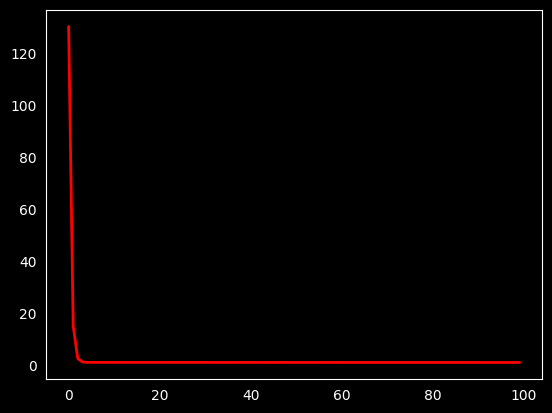

In [63]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tensor_x = torch.tensor(x).to(device)
tensor_y = torch.tensor(y).to(device)

# Random Parameters for start
torch.manual_seed(42)

b = torch.randn(1, requires_grad=True, dtype=torch.float, device=device)
w = torch.randn(1, requires_grad=True, dtype=torch.float, device=device)


#Collect Error
losses = []

lr = 0.01
n_epochs = 100
for epoch in range(n_epochs):
    # Step 1 - Computes model's predicted output - forward pass
    yhat = b + w * tensor_x


    # descent. How wrong is our model? That's the error!
    error = (yhat - tensor_y)

    # It is a regression, so it computes mean squared error (MSE)
    loss = (error ** 2).mean()
    losses.append(loss.detach().item())

    # Step 3 - Computes gradients for both "b" and "w"
    b_grad = 2 * error.mean()
    w_grad = 2 * (tensor_x * error).mean()


    # Step 4 - Updates parameters using gradients
    with torch.no_grad():
        b -= lr * b_grad
        w -= lr * w_grad



w_np = w.detach().item()
b_np = b.detach().item()
print(f'{w_np}*x + {b_np}')

plt.plot(np.arange(0, n_epochs, 1), losses, color='red', linewidth=2)
plt.grid(False)
plt.show()

## Plot results

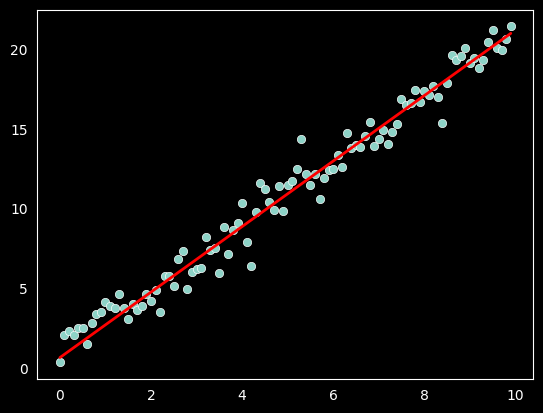

In [64]:
sns.scatterplot(x = x, y = y)

x_s = np.arange(0, 10, 1)
plt.plot(x, w_np*x + b_np, color='red', linewidth=2)
plt.grid(False)
plt.show()

# Gradient Decent with autograd

2.0497384071350098*x + 0.6790927052497864


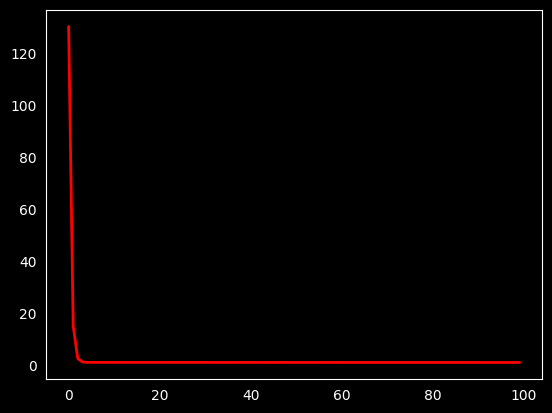

In [65]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tensor_x = torch.tensor(x).to(device)
tensor_y = torch.tensor(y).to(device)

# Random Parameters for start
torch.manual_seed(42)

b = torch.randn(1, requires_grad=True, dtype=torch.float, device=device)
w = torch.randn(1, requires_grad=True, dtype=torch.float, device=device)


#Collect Error
losses = []

lr = 0.01
n_epochs = 100
for epoch in range(n_epochs):
    # Step 1 - Computes model's predicted output - forward pass
    yhat = b + w * tensor_x


    # descent. How wrong is our model? That's the error!
    error = (yhat - tensor_y)

    # It is a regression, so it computes mean squared error (MSE)
    loss = (error ** 2).mean()
    losses.append(loss.detach().item())

    # Step 3 - Computes gradients for both "b" and "w"
    loss.backward()


    # Step 4 - Updates parameters using gradients
    with torch.no_grad():
        b -= lr * b.grad
        w -= lr * w.grad

    # Step 5 - zero gradients
    b.grad.zero_()
    w.grad.zero_()


w_np = w.detach().item()
b_np = b.detach().item()
print(f'{w_np}*x + {b_np}')

plt.plot(np.arange(0, n_epochs, 1), losses, color='red', linewidth=2)
plt.grid(False)
plt.show()

# Plot Result

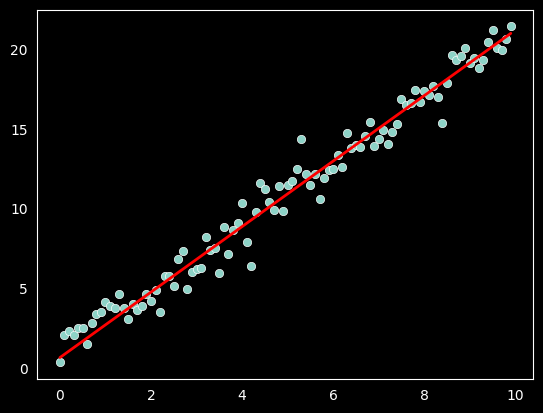

In [66]:
sns.scatterplot(x = x, y = y)

x_s = np.arange(0, 10, 1)
plt.plot(x, w_np*x + b_np, color='red', linewidth=2)
plt.grid(False)
plt.show()